In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!pip install transformers

import torch
from transformers import BertForQuestionAnswering
from transformers import BertTokenizer

In [ ]:
data = pd.read_json('http://downloads.cs.stanford.edu/nlp/data/coqa/coqa-train-v1.0.json')
data.head()

,version,data
0,1,"{'source': 'wikipedia', 'id': '3zotghdk5ibi9ce..."
1,1,"{'source': 'cnn', 'id': '3wj1oxy92agboo5nlq4r7..."
2,1,"{'source': 'gutenberg', 'id': '3bdcf01ogxu7zdn..."
3,1,"{'source': 'cnn', 'id': '3ewijtffvo7wwchw6rtya..."
4,1,"{'source': 'gutenberg', 'id': '3urfvvm165iantk..."


In [ ]:
del data["version"]

In [ ]:
cols = ["text","question","answer"]

comp_list = []
for index, row in data.iterrows():
    for i in range(len(row["data"]["questions"])):
        temp_list = []
        temp_list.append(row["data"]["story"])
        temp_list.append(row["data"]["questions"][i]["input_text"])
        temp_list.append(row["data"]["answers"][i]["input_text"])
        comp_list.append(temp_list)
new_df = pd.DataFrame(comp_list, columns=cols)

In [ ]:
new_df.to_csv("CoQA_data.csv", index=False)

In [ ]:
data = pd.read_csv("CoQA_data.csv")
data.head()

,text,question,answer
0,"The Vatican Apostolic Library (), more commonl...",When was the Vat formally opened?,It was formally established in 1475
1,"The Vatican Apostolic Library (), more commonl...",what is the library for?,research
2,"The Vatican Apostolic Library (), more commonl...",for what subjects?,"history, and law"
3,"The Vatican Apostolic Library (), more commonl...",and?,"philosophy, science and theology"
4,"The Vatican Apostolic Library (), more commonl...",what was started in 2014?,a project


In [ ]:
print("Number of question and answers: ", len(data))


Number of question and answers:  108647


# Building the chatbot

In [ ]:
model = BertForQuestionAnswering.from_pretrained('bert-large-uncased-whole-word-masking-finetuned-squad')
tokenizer = BertTokenizer.from_pretrained('bert-large-uncased-whole-word-masking-finetuned-squad')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-large-uncased-whole-word-masking-finetuned-squad were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
# random_num = np.random.randint(0,len(data))

# question = data["question"][random_num]
# text = data["text"][random_num]

In [ ]:
question = "How many parameters does BERT-large have?"
text = "BERT-large is really big... it has 24-layers and an embedding size of 1,024, for a total of 340M parameters! Altogether it is 1.34GB, so expect it to take a couple minutes to download to your Colab instance."

In [ ]:
print(question, "\n", text)

How many parameters does BERT-large have? 
 BERT-large is really big... it has 24-layers and an embedding size of 1,024, for a total of 340M parameters! Altogether it is 1.34GB, so expect it to take a couple minutes to download to your Colab instance.


In [ ]:
input_ids = tokenizer.encode(question, text)
print("The input has a total of {} tokens.".format(len(input_ids)))

The input has a total of 70 tokens.


In [ ]:
tokens = tokenizer.convert_ids_to_tokens(input_ids)

for token, id in zip(tokens, input_ids):
    print('{:8}{:8,}'.format(token,id))

[CLS]        101
how        2,129
many       2,116
parameters  11,709
does       2,515
bert      14,324
-          1,011
large      2,312
have       2,031
?          1,029
[SEP]        102
bert      14,324
-          1,011
large      2,312
is         2,003
really     2,428
big        2,502
.          1,012
.          1,012
.          1,012
it         2,009
has        2,038
24         2,484
-          1,011
layers     9,014
and        1,998
an         2,019
em         7,861
##bed      8,270
##ding     4,667
size       2,946
of         1,997
1          1,015
,          1,010
02         6,185
##4        2,549
,          1,010
for        2,005
a          1,037
total      2,561
of         1,997
340       16,029
##m        2,213
parameters  11,709
!            999
altogether  10,462
it         2,009
is         2,003
1          1,015
.          1,012
34         4,090
##gb      18,259
,          1,010
so         2,061
expect     5,987
it         2,009
to         2,000
take       2,202
a       

In [ ]:
sep_idx = input_ids.index(tokenizer.sep_token_id)
print(sep_idx)
num_seg_a = sep_idx+1
print(num_seg_a)
num_seg_b = len(input_ids) - num_seg_a
print(num_seg_b)

segment_ids = [0]*num_seg_a + [1]*num_seg_b
print(segment_ids)

assert len(segment_ids) == len(input_ids)

10
11
59
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [ ]:
output = model(torch.tensor([input_ids]), token_type_ids=torch.tensor([segment_ids]))

In [ ]:
answer_start = torch.argmax(output.start_logits)
answer_end = torch.argmax(output.end_logits)

In [ ]:
if answer_end >= answer_start:
    answer = " ".join(tokens[answer_start:answer_end+1])
else:
    print("I am unable to find the answer to this question. Can you please ask another question?")

print("Text:\n{}".format(text.capitalize()))
print("\nQuestion:\n{}".format(question.capitalize()))
print("\nAnswer:\n{}.".format(answer.capitalize()))

Text:
Bert-large is really big... it has 24-layers and an embedding size of 1,024, for a total of 340m parameters! altogether it is 1.34gb, so expect it to take a couple minutes to download to your colab instance.

Question:
How many parameters does bert-large have?

Answer:
340 ##m.


# Visualization of the tokens


In [ ]:
start_scores = output.start_logits.detach().numpy().flatten()
end_scores = output.end_logits.detach().numpy().flatten()

token_labels = []
for i, token in enumerate(tokens):
    token_labels.append("{}-{}".format(token,i))

In [ ]:
print(len(token_labels))


70


<ipython-input-22-77abf5582e8a>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x=token_labels[:80], y=start_scores[:80], ci=None)
<ipython-input-22-77abf5582e8a>:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")


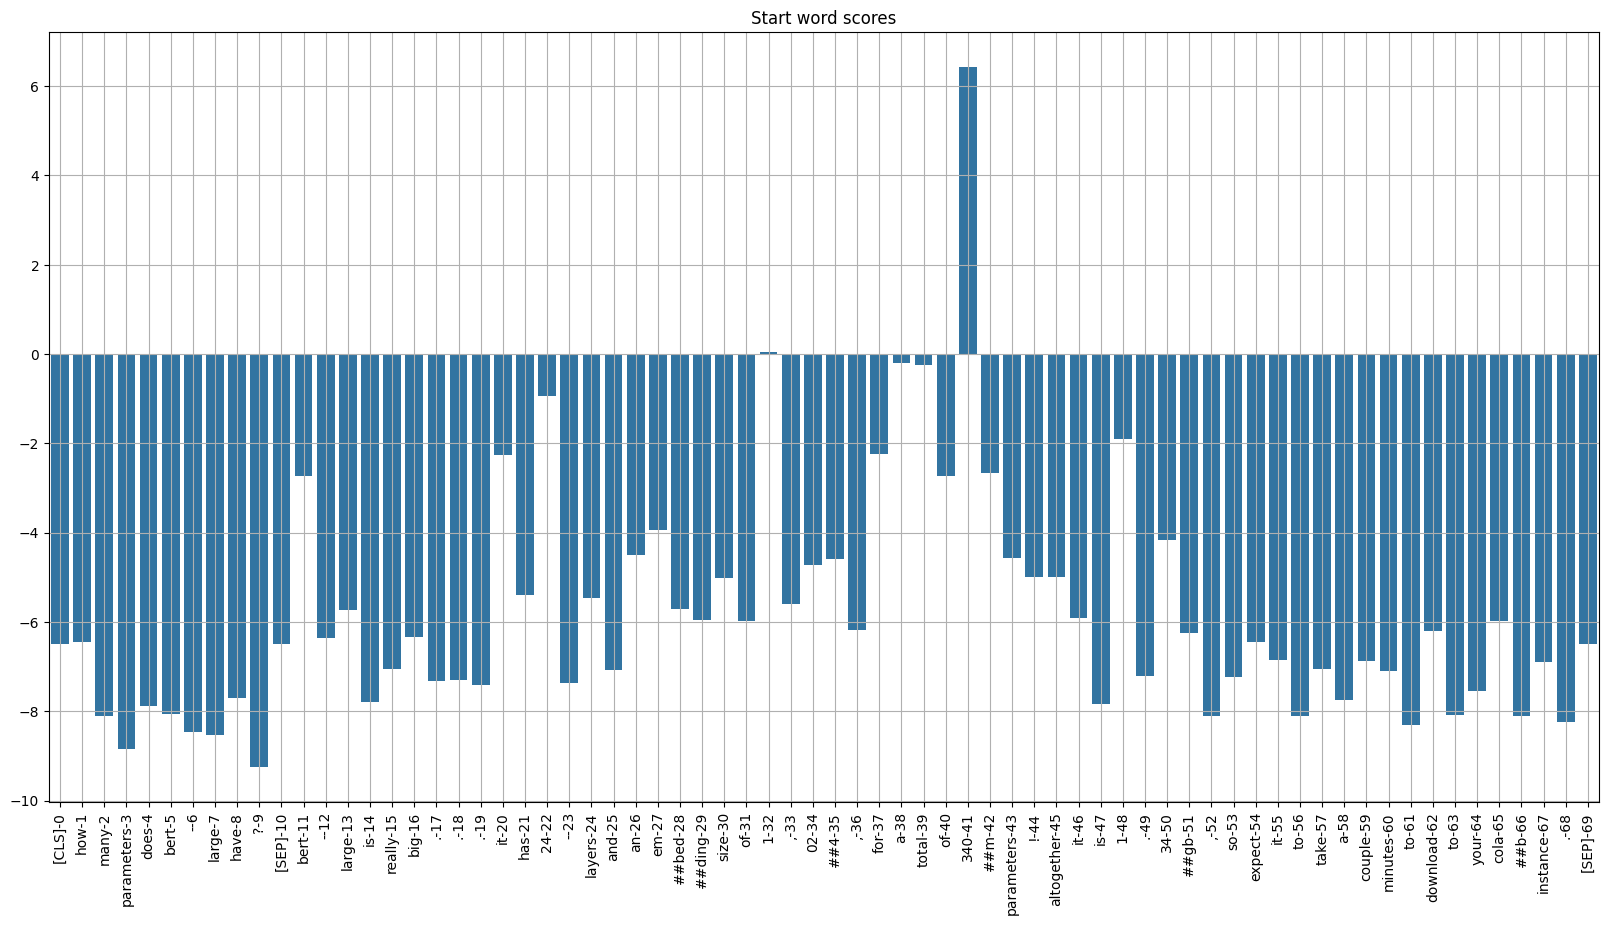

In [ ]:
plt.rcParams["figure.figsize"] = (20,10)
ax = sns.barplot(x=token_labels[:80], y=start_scores[:80], ci=None)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")
ax.grid(True)
plt.title("Start word scores")
plt.show()

<ipython-input-23-b00cd955626b>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x=token_labels[:80], y=end_scores[:80], ci=None)
<ipython-input-23-b00cd955626b>:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")


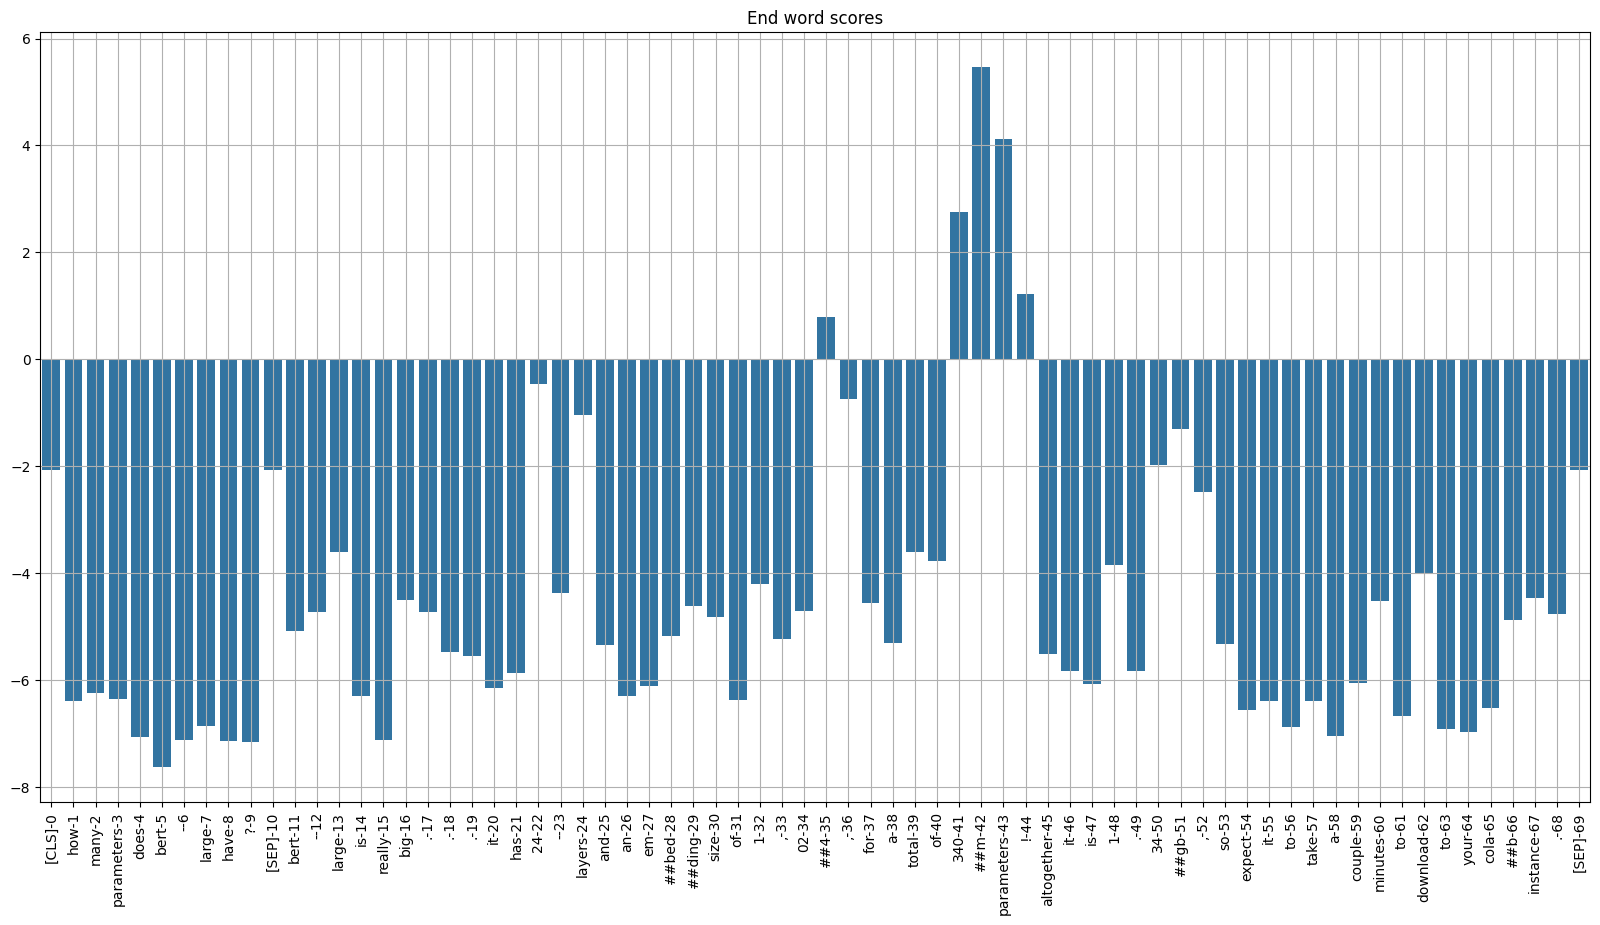

In [ ]:
plt.rcParams["figure.figsize"] = (20,10)
ax = sns.barplot(x=token_labels[:80], y=end_scores[:80], ci=None)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")
ax.grid(True)
plt.title("End word scores")
plt.show()

# Code to join the broken words


In [ ]:
answer = tokens[answer_start]

for i in range(answer_start+1, answer_end+1):
    if tokens[i][0:2] == "##":
        answer += tokens[i][2:]
    else:
        answer += " " + tokens[i]

In [ ]:
def question_answer(question, text):

    input_ids = tokenizer.encode(question, text)

    tokens = tokenizer.convert_ids_to_tokens(input_ids)


    sep_idx = input_ids.index(tokenizer.sep_token_id)

    num_seg_a = sep_idx+1

    num_seg_b = len(input_ids) - num_seg_a

    segment_ids = [0]*num_seg_a + [1]*num_seg_b

    assert len(segment_ids) == len(input_ids)

    output = model(torch.tensor([input_ids]), token_type_ids=torch.tensor([segment_ids]))

    answer_start = torch.argmax(output.start_logits)
    answer_end = torch.argmax(output.end_logits)

    if answer_end >= answer_start:
        answer = tokens[answer_start]
        for i in range(answer_start+1, answer_end+1):
            if tokens[i][0:2] == "##":
                answer += tokens[i][2:]
            else:
                answer += " " + tokens[i]

    if answer.startswith("[CLS]"):
        answer = "Unable to find the answer to your question."
    print("\nAnswer:\n{}".format(answer.capitalize()))

In [ ]:
text = """New York (CNN) -- More than 80 Michael Jackson collectibles -- including the late pop star's famous rhinestone-studded glove from a 1983 performance -- were auctioned off Saturday, reaping a total $2 million. Profits from the auction at the Hard Rock Cafe in New York's Times Square crushed pre-sale expectations of only $120,000 in sales. The highly prized memorabilia, which included items spanning the many stages of Jackson's career, came from more than 30 fans, associates and family members, who contacted Julien's Auctions to sell their gifts and mementos of the singer. Jackson's flashy glove was the big-ticket item of the night, fetching $420,000 from a buyer in Hong Kong, China. Jackson wore the glove at a 1983 performance during \"Motown 25,\" an NBC special where he debuted his revolutionary moonwalk. Fellow Motown star Walter \"Clyde\" Orange of the Commodores, who also performed in the special 26 years ago, said he asked for Jackson's autograph at the time, but Jackson gave him the glove instead. "The legacy that [Jackson] left behind is bigger than life for me,\" Orange said. \"I hope that through that glove people can see what he was trying to say in his music and what he said in his music.\" Orange said he plans to give a portion of the proceeds to charity. Hoffman Ma, who bought the glove on behalf of Ponte 16 Resort in Macau, paid a 25 percent buyer's premium, which was tacked onto all final sales over $50,000. Winners of items less than $50,000 paid a 20 percent premium."""
question = "Where was the Auction held?"

question_answer(question, text)


Answer:
Hard rock cafe in new york ' s times square


In [ ]:
print("Original answer:\n", data.loc[data["question"] == question]["answer"].values[0])


Original answer:
 Hard Rock Cafe


In [ ]:
text = input("Please enter your text: \n")
question = input("\nPlease enter your question: \n")

while True:
    question_answer(question, text)

    flag = True
    flag_N = False

    while flag:
        response = input("\nDo you want to ask another question based on this text (Y/N)? ")
        if response[0] == "Y":
            question = input("\nPlease enter your question: \n")
            flag = False
        elif response[0] == "N":
            print("\nBye!")
            flag = False
            flag_N = True

    if flag_N == True:
        break

KeyboardInterrupt: Interrupted by user

In [ ]:
!pip install streamlit pyngrok --quiet
!npm install localtunnel --quiet  # Alternative to ngrok

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 126.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.0 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹
added 22 packages in 2s
⠹
⠹3 packages are looking for funding
⠹  run `npm fund` for details
⠹

In [1]:
%%writefile app.py
import streamlit as st
import torch
import torch
from transformers import BertForQuestionAnswering
from transformers import BertTokenizer

model = BertForQuestionAnswering.from_pretrained('bert-large-uncased-whole-word-masking-finetuned-squad')
tokenizer = BertTokenizer.from_pretrained('bert-large-uncased-whole-word-masking-finetuned-squad')

# Your QA function
def question_answer(question, text):

    input_ids = tokenizer.encode(question, text)

    tokens = tokenizer.convert_ids_to_tokens(input_ids)

    sep_idx = input_ids.index(tokenizer.sep_token_id)

    num_seg_a = sep_idx + 1

    num_seg_b = len(input_ids) - num_seg_a

    segment_ids = [0] * num_seg_a + [1] * num_seg_b

    assert len(segment_ids) == len(input_ids)

    output = model(torch.tensor([input_ids]), token_type_ids=torch.tensor([segment_ids]))

    answer_start = torch.argmax(output.start_logits)
    answer_end = torch.argmax(output.end_logits)

    if answer_end >= answer_start:
        answer = tokens[answer_start]
        for i in range(answer_start + 1, answer_end + 1):
            if tokens[i][:2] == "##":
                answer += tokens[i][2:]
            else:
                answer += " " + tokens[i]

    # Handle case where no answer is found
    if answer.startswith("[CLS]"):
        answer = "Unable to find the answer to your question."

    return answer.capitalize()

# Streamlit UI
st.set_page_config(layout="wide")
st.title("Question Answering System")

col1, col2 = st.columns(2)
with col1:
    question = st.text_input("Your Question:", placeholder="Ask me anything...")
with col2:
    text = st.text_area("Context Text:", height=150, placeholder="Paste the text you want to ask about...")

if st.button("Get Answer", type="primary"):
    if question and text:
        with st.spinner("Analyzing..."):
            answer = question_answer(question, text)
            st.success("Answer:")
            st.markdown(f"**{answer}**")
    else:
        st.warning("Please enter both a question and context text")

Writing app.py


In [ ]:
from pyngrok import ngrok

!pkill streamlit
ngrok.set_auth_token("2w2wmZyskOO6LU3i9X9uLG7kwA1_4do6i7CGv56bTL1uBfDWe")


public_url = ngrok.connect(addr=8501)
print("Streamlit app URL:", public_url)

!streamlit run app.py &

Streamlit app URL: NgrokTunnel: "https://b573-34-125-140-177.ngrok-free.app" -> "http://localhost:8501"



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.125.140.177:8501

2025-04-23 07:38:11.056334: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745393891.078861    2039 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745393891.085715    2039 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Some weights of the model checkpoint at bert-large-uncased-whole-word-masking-finetuned-squad were not used when initializing BertForQuestionAnswering: ['be